In [ ]:
# Import libraries
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:
# Load Give Me Some Credit
gmsc = pd.read_csv(
    r'C:\Users\yashc\OneDrive\Desktop\code\Risk-Copilot\data\raw\GiveMeSomeCredit\cs-training.csv',
    index_col=0
)   # used absolute path
print(gmsc.shape)           # Should be (150000, 11)
print(gmsc.dtypes)
print(gmsc.isnull().sum())  # Check missing values
gmsc.head()

(150000, 11)
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNot

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
# Study delinquency rate (your synthetic data must match this)
print(f"Delinquency rate: {gmsc['SeriousDlqin2yrs'].mean():.3f}")

# Expected: ~0.067 (6.7%) — use this for your synthetic delinquency_flag generation

Delinquency rate: 0.067


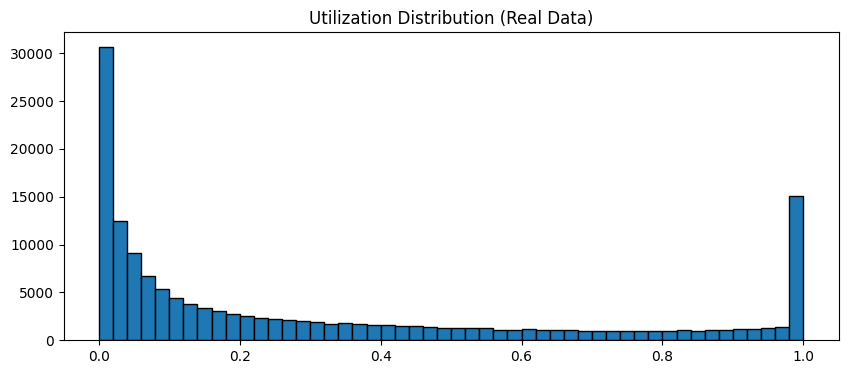

In [ ]:
# Study utilization distribution
util = gmsc['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(util, bins=50, edgecolor='black')
ax.set_title('Utilization Distribution (Real Data)')
plt.savefig(r'C:\Users\yashc\OneDrive\Desktop\code\Risk-Copilot\notebooks/utilization_dist.png', dpi=100, bbox_inches='tight')  #used absolute path
plt.show()

# Key insight: most customers < 0.4 utilization, spike near 1.0 for distressed accounts